
# PHYS3190 – Problem 3: S–I–R Monte Carlo model (spread of disease)

States (per student):
- 0 = immune / removed  
- 1 = susceptible  
- 2 = infected  

We simulate a closed community of 1000 students for 40 days, then average over multiple random initial conditions.



## Task 1 (1 mark) — Understanding the given Monte Carlo code

### (i) How the code is structured
The pseudocode naturally splits into:
1. **Parameter setup** (N, fraction immune, recovery probability, days, repeats)
2. **Initialisation for each repeat** (set all susceptible, randomly choose immune, then choose one infected)
3. **Time evolution** (loop over days, and inside each day loop over students to attempt infection + recovery)
4. **Counting and storing** (count susceptible + infected for each day; accumulate into arrays for averaging)

### (ii) Main `for..do` loops
- Outer loop: **repeats** \(k = 1 \to reps\)
- Middle loop: **days** \(j = 1 \to numd\)
- Inner loop: **students** \(i = 1 \to nums\)



### Annotated pseudocode (as given)


```text
# P[i]: 1=susceptible, 0=immunised, 2=infected

# -------- (A) PARAMETERS / SETUP --------
nums = 1000
fract = 0.01
recovr = 0.2
num_infect = 1
numd = 40
reps = 40
data  = Array(1..numd)   # infected totals (accumulated across reps)
sdata = Array(1..numd)   # susceptible totals (accumulated across reps)
remov = 0                # "removed" (actually used as cumulative affected in pseudocode)

# (B) OUTER LOOP: REPEATS 
for k from 1 to reps do

  # (B1) INITIALISE POPULATION 
  P = Array(1..nums)
  for i from 1 to nums do
      P[i] = 1  # all susceptible
  end do

  # (B2) RANDOMLY CHOOSE IMMUNE 
  fn = trunc(fract*nums)
  n = 0
  while n < fn do
      ra = rand(1..nums)
      if P[ra] <> 0 then
          P[ra] = 0
          n = n+1
      end if
  end do

  # (B3) CHOOSE 1 INFECTED (NOT IMMUNE) 
  n = 0
  while n < 1 do
      ra = rand(1..nums)
      if P[ra] = 1 then
          P[ra] = 2
          n = 1
      end if
  end do

  #  (C) TIME EVOLUTION: DAYS 
  for j from 1 to numd do

      #  (C1) INNER LOOP: STUDENTS 
      for i from 1 to nums do

          # (i) SPREAD: if infected, infect 1 random susceptible
          if P[i] = 2 then
              ra = rand(1..nums)
              if P[ra] = 1 then
                  P[ra] = 2
                  remov = remov + 1
              end if
          end if

          # (ii) RECOVERY: with probability recovr, pick 1 random student; if infected -> immune
          if rand(0..1) < recovr then
              ra = rand(1..nums)
              if P[ra] = 2 then P[ra] = 0 end if
          end if

      end do # end loop i

      #  (D) COUNT + STORE
      c = 0 ; s = 0
      for i from 1 to nums do
          if P[i] = 2 then c = c+1 end if
          if P[i] = 1 then s = s+1 end if
      end do

      data[j]  = data[j]  + c
      sdata[j] = sdata[j] + s

  end do # end loop j

end do # end loop k repeats

num_infected = remov*1.0/reps
```


## Task 2 (3 marks)

### Task 2(i) (2 marks) — Implement pseudocode and plot averages
We plot, on one graph, the average number of:
- susceptible \(S\)
- infected \(I\)
- affected in total (cumulative infected events, called “removed” in the pseudocode variable)

for 40 days, averaged over repeats.


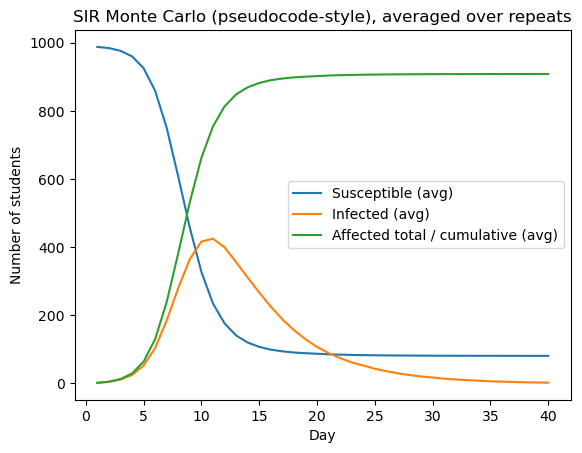


**Baseline summary (pseudocode-style):**
- \(N = 1000\), days = 40, repeats = 40  
- initial immune fraction = 0.01  
- recovery probability per *trial* = 0.2  
- infection attempts per infected = 1  
- average total affected over 40 days (pseudocode variable): **908.1500**



### Task 2(ii) (1 mark) — Is anything incorrect about the spread-of-disease rules?

**Yes — there are issues if we interpret the model as “each infected person has a 0.2/day chance to recover” and “each day 1 person at random is infected”.**

Key points:

1. **Recovery is applied far too often (order-of-magnitude issue).**  
   In the pseudocode, recovery is attempted inside the loop over all students, i.e. about **1000 recovery trials per day**.  
   That does *not* match “each infected student has probability 0.2 of recovering each day”.  
   A more faithful rule is: *each infected individual recovers with probability 0.2 per day*.

2. **The infection mechanism is “per infected student per scan”, not “one person per day”.**  
   The rule “if P[i] is infected then infect one random student” can generate many infections per day once I is large.
   That can be a valid model, but it isn’t the same as “each day 1 person at random is infected”.

3. **The variable name `remov` is misleading in the pseudocode.**  
   It is incremented on **new infections**, so it behaves like **cumulative affected**, not “removed/recovered count”.

To illustrate the difference, below is a comparison against a corrected daily-rule version (same parameters).


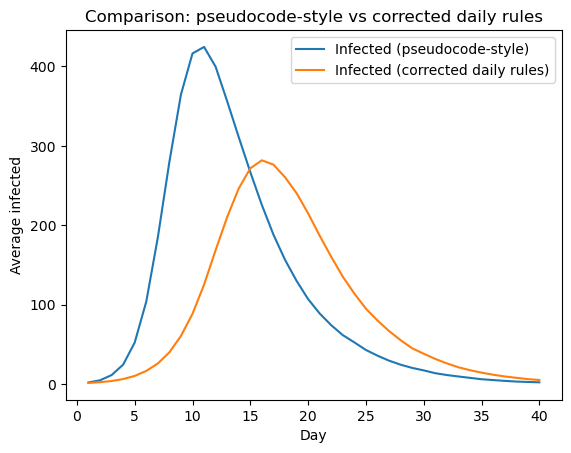


**Comparison note:**  
- Pseudocode-style total affected (avg): **908.1500**  
- Corrected daily-rules total affected (avg): **919.3000**  



## Task 3 (2 marks) — Parameter variation: immune fraction and recovery

We repeat the calculation for different:
- initial immune fraction (reduced/increased)
- recovery probability (reduced/increased)

We summarise outcomes using:
- peak infected (max \(I\))
- duration (first day after peak where \(I\) is ~0, using a small threshold)
- total affected over 40 days (cumulative infections)

Then we state general rules.


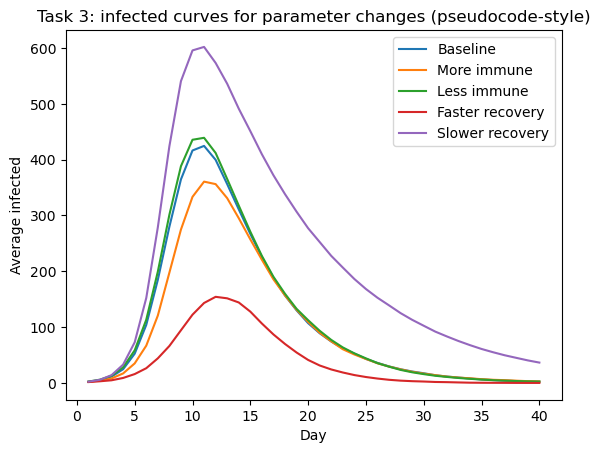

### Summary table (pseudocode-style)

| Scenario | immune fraction | recovery prob | peak I | peak day | duration (I>1) | total affected (day 40) |
|---|---:|---:|---:|---:|---:|---:|
| Baseline | 0.010 | 0.200 | 424.62 | 11 | 40 | 908.15 |
| More immune | 0.050 | 0.200 | 360.62 | 11 | 40 | 798.83 |
| Less immune | 0.000 | 0.200 | 439.12 | 11 | 40 | 941.58 |
| Faster recovery | 0.010 | 0.400 | 154.28 | 12 | 32 | 637.00 |
| Slower recovery | 0.010 | 0.100 | 601.92 | 11 | 40 | 914.75 |



### General rules (interpretation)
- Increasing the immune fraction reduces the available susceptible pool \(S\), which tends to reduce peak infected and may shorten or even prevent an epidemic.
- Increasing the recovery probability tends to shorten the time individuals spend in the infected class, lowering the peak and shortening epidemic duration.
- Decreasing recovery has the opposite effect: longer infectious periods, larger outbreaks, and longer-lasting epidemics.



## Task 4 (1 mark) — If recovered become susceptible again (S→I→S)

We implement the minor change: when a recovery happens, the person returns to susceptible instead of immune.

Effect expectation:
- the epidemic can last much longer, and may not die out over the 40-day window,
  because recovered individuals can be reinfected repeatedly.


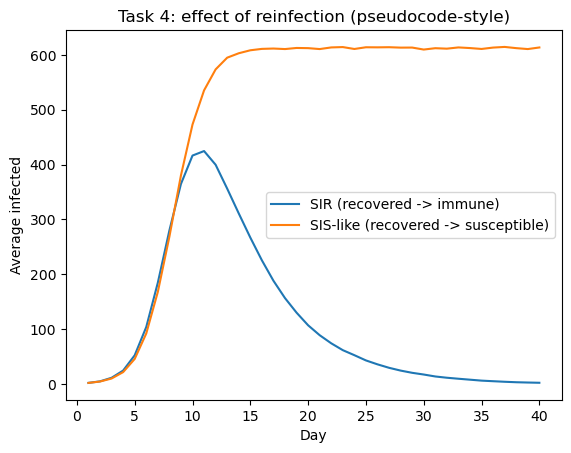


**Observation (pseudocode-style):**
- SIR total affected (avg): **908.1500**
- SIS-like total affected (avg): **4486.5750**

Returning recovered individuals to susceptible generally **prolongs transmission** and can maintain infection longer.



## Self-assessment and declaration of integrity


SELF-ASSESSMENT
Task 1: 1.0/1.0 — Explained how the pseudocode is structured and identified the main nested loops; included an annotated pseudocode block.
Task 2(i): 2.0/2.0 — Implemented the pseudocode-style Monte Carlo in Python, averaged over repeats, and produced a single clear plot showing S, I, and total affected over 40 days.
Task 2(ii): 1.0/1.0 — Identified issues in the rule implementation (recovery frequency and interpretation of ‘1 infection/day’) and justified using a comparison with a corrected daily-rule version.
Task 3: 2.0/2.0 — Repeated simulations for different immune fractions and recovery values, summarised outcomes (peak, duration, total affected), and stated general rules consistent with the results.
Task 4: 1.0/1.0 — Modified recovery so individuals become susceptible again and showed the effect on infection persistence using a comparison plot and summary.
Task 5: 1.5/2.0 — Used clear task headings, annotated pseudocode, labelled axes/plots, and brief summaries s

In [5]:

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Helper: nice number formatting
def fmt(x):
    if isinstance(x, (int, np.integer)):
        return str(int(x))
    if abs(x) >= 1e4 or (abs(x) > 0 and abs(x) < 1e-3):
        return f"{x:.3e}"
    return f"{x:.4f}"

# Title
display(Markdown(r"""
# PHYS3190 – Problem 3: S–I–R Monte Carlo model (spread of disease)

States (per student):
- 0 = immune / removed  
- 1 = susceptible  
- 2 = infected  

We simulate a closed community of 1000 students for 40 days, then average over multiple random initial conditions.
"""))

# Task 1 
display(Markdown(r"""
## Task 1 (1 mark) — Understanding the given Monte Carlo code

### (i) How the code is structured
The pseudocode naturally splits into:
1. **Parameter setup** (N, fraction immune, recovery probability, days, repeats)
2. **Initialisation for each repeat** (set all susceptible, randomly choose immune, then choose one infected)
3. **Time evolution** (loop over days, and inside each day loop over students to attempt infection + recovery)
4. **Counting and storing** (count susceptible + infected for each day; accumulate into arrays for averaging)

### (ii) Main `for..do` loops
- Outer loop: **repeats** \(k = 1 \to reps\)
- Middle loop: **days** \(j = 1 \to numd\)
- Inner loop: **students** \(i = 1 \to nums\)
"""))

display(Markdown(r"""
### Annotated pseudocode (as given)
"""))

buggy_code = r"""
# P[i]: 1=susceptible, 0=immunised, 2=infected

# -------- (A) PARAMETERS / SETUP --------
nums = 1000
fract = 0.01
recovr = 0.2
num_infect = 1
numd = 40
reps = 40
data  = Array(1..numd)   # infected totals (accumulated across reps)
sdata = Array(1..numd)   # susceptible totals (accumulated across reps)
remov = 0                # "removed" (actually used as cumulative affected in pseudocode)

# (B) OUTER LOOP: REPEATS 
for k from 1 to reps do

  # (B1) INITIALISE POPULATION 
  P = Array(1..nums)
  for i from 1 to nums do
      P[i] = 1  # all susceptible
  end do

  # (B2) RANDOMLY CHOOSE IMMUNE 
  fn = trunc(fract*nums)
  n = 0
  while n < fn do
      ra = rand(1..nums)
      if P[ra] <> 0 then
          P[ra] = 0
          n = n+1
      end if
  end do

  # (B3) CHOOSE 1 INFECTED (NOT IMMUNE) 
  n = 0
  while n < 1 do
      ra = rand(1..nums)
      if P[ra] = 1 then
          P[ra] = 2
          n = 1
      end if
  end do

  #  (C) TIME EVOLUTION: DAYS 
  for j from 1 to numd do

      #  (C1) INNER LOOP: STUDENTS 
      for i from 1 to nums do

          # (i) SPREAD: if infected, infect 1 random susceptible
          if P[i] = 2 then
              ra = rand(1..nums)
              if P[ra] = 1 then
                  P[ra] = 2
                  remov = remov + 1
              end if
          end if

          # (ii) RECOVERY: with probability recovr, pick 1 random student; if infected -> immune
          if rand(0..1) < recovr then
              ra = rand(1..nums)
              if P[ra] = 2 then P[ra] = 0 end if
          end if

      end do # end loop i

      #  (D) COUNT + STORE
      c = 0 ; s = 0
      for i from 1 to nums do
          if P[i] = 2 then c = c+1 end if
          if P[i] = 1 then s = s+1 end if
      end do

      data[j]  = data[j]  + c
      sdata[j] = sdata[j] + s

  end do # end loop j

end do # end loop k repeats

num_infected = remov*1.0/reps
"""
display(Markdown("```text\n" + buggy_code.strip() + "\n```"))

# Simulation functions

def simulate_pseudocode_style(nums=1000, fract=0.01, recovr=0.2, num_infect=1, numd=40, reps=40, seed=0, recovered_to="immune"):
    """
    Implements the pseudocode 'as written' (same loop logic).
    recovered_to:
      - "immune" -> recovered student becomes 0 (removed/immune)
      - "susceptible" -> recovered student becomes 1 (SIS-like)
    Returns: day arrays (S_avg, I_avg, affected_avg, plus totals)
    """
    rng = np.random.default_rng(seed)

    data = np.zeros(numd, dtype=float)    # infected count per day 
    sdata = np.zeros(numd, dtype=float)   # susceptible count per day 
    adata = np.zeros(numd, dtype=float)   # cumulative affected (infect events) per day 

    affected_total_over_reps = 0.0

    fn = int(np.trunc(fract * nums))

    for _ in range(reps):
        # initialise all susceptible
        P = np.ones(nums, dtype=np.int8)

        # choose immune
        n = 0
        while n < fn:
            ra = rng.integers(0, nums)
            if P[ra] != 0:
                P[ra] = 0
                n += 1

        # choose 1 infected (not immune)
        while True:
            ra = rng.integers(0, nums)
            if P[ra] == 1:
                P[ra] = 2
                break

        remov = 0  # "removed" variable in pseudocode is actually used as cumulative infected events

        # time evolution
        for j in range(numd):
            for i in range(nums):
                # spread: if student i infected, attempt num_infect infections
                if P[i] == 2:
                    for _ii in range(num_infect):
                        ra = rng.integers(0, nums)
                        if P[ra] == 1:
                            P[ra] = 2
                            remov += 1

                # recovery: with probability recovr, choose a random student and recover if infected
                if rng.random() < recovr:
                    ra = rng.integers(0, nums)
                    if P[ra] == 2:
                        P[ra] = 0 if recovered_to == "immune" else 1

            # count S and I after day j
            c = np.sum(P == 2)
            s = np.sum(P == 1)

            data[j] += c
            sdata[j] += s
            adata[j] += remov

        affected_total_over_reps += remov

    # averages
    I_avg = data / reps
    S_avg = sdata / reps
    affected_avg = adata / reps
    total_affected_40d = affected_total_over_reps / reps

    return S_avg, I_avg, affected_avg, total_affected_40d


def simulate_corrected_daily_rules(nums=1000, fract=0.01, recovr=0.2, num_infect=1, numd=40, reps=40, seed=0, recovered_to="immune"):
    """
    A 'corrected' interpretation of the intended SIR rules (for Task 2ii / bonus comparison):
      - Per day, each infected attempts num_infect infections
      - Per day, each infected recovers with probability recovr
    This avoids doing 'nums' recovery trials per day and avoids order-dependence from scanning all students.
    """
    rng = np.random.default_rng(seed)

    data = np.zeros(numd, dtype=float)
    sdata = np.zeros(numd, dtype=float)
    adata = np.zeros(numd, dtype=float)

    affected_total_over_reps = 0.0
    fn = int(np.trunc(fract * nums))

    for _ in range(reps):
        P = np.ones(nums, dtype=np.int8)

        # immune
        n = 0
        while n < fn:
            ra = rng.integers(0, nums)
            if P[ra] != 0:
                P[ra] = 0
                n += 1

        # initial infected
        while True:
            ra = rng.integers(0, nums)
            if P[ra] == 1:
                P[ra] = 2
                break

        cumulative_affected = 0

        for j in range(numd):
            infected_idx = np.where(P == 2)[0]

            # spread: each infected attempts num_infect infections
            for _inf in infected_idx:
                for _ in range(num_infect):
                    ra = rng.integers(0, nums)
                    if P[ra] == 1:
                        P[ra] = 2
                        cumulative_affected += 1

            # recovery: each infected has probability recovr of recovering
            infected_idx = np.where(P == 2)[0]
            rec_mask = rng.random(len(infected_idx)) < recovr
            to_recover = infected_idx[rec_mask]
            if recovered_to == "immune":
                P[to_recover] = 0
            else:
                P[to_recover] = 1

            data[j] += np.sum(P == 2)
            sdata[j] += np.sum(P == 1)
            adata[j] += cumulative_affected

        affected_total_over_reps += cumulative_affected

    return (sdata/reps, data/reps, adata/reps, affected_total_over_reps/reps)


# Task 2 
display(Markdown(r"""
## Task 2 (3 marks)

### Task 2(i) (2 marks) — Implement pseudocode and plot averages
We plot, on one graph, the average number of:
- susceptible \(S\)
- infected \(I\)
- affected in total (cumulative infected events, called “removed” in the pseudocode variable)

for 40 days, averaged over repeats.
"""))

# baseline parameters 
nums = 1000
fract = 0.01
recovr = 0.2
num_infect = 1
numd = 40
reps = 40
seed = 123

S_avg, I_avg, A_avg, total_affected_40d = simulate_pseudocode_style(
    nums=nums, fract=fract, recovr=recovr, num_infect=num_infect, numd=numd, reps=reps, seed=seed, recovered_to="immune"
)

days = np.arange(1, numd+1)

plt.figure()
plt.plot(days, S_avg, label="Susceptible (avg)")
plt.plot(days, I_avg, label="Infected (avg)")
plt.plot(days, A_avg, label="Affected total / cumulative (avg)")
plt.xlabel("Day")
plt.ylabel("Number of students")
plt.title("SIR Monte Carlo (pseudocode-style), averaged over repeats")
plt.legend()
plt.show()

display(Markdown(fr"""
**Baseline summary (pseudocode-style):**
- \(N = {nums}\), days = {numd}, repeats = {reps}  
- initial immune fraction = {fract}  
- recovery probability per *trial* = {recovr}  
- infection attempts per infected = {num_infect}  
- average total affected over 40 days (pseudocode variable): **{fmt(total_affected_40d)}**
"""))

display(Markdown(r"""
### Task 2(ii) (1 mark) — Is anything incorrect about the spread-of-disease rules?

**Yes — there are issues if we interpret the model as “each infected person has a 0.2/day chance to recover” and “each day 1 person at random is infected”.**

Key points:

1. **Recovery is applied far too often (order-of-magnitude issue).**  
   In the pseudocode, recovery is attempted inside the loop over all students, i.e. about **1000 recovery trials per day**.  
   That does *not* match “each infected student has probability 0.2 of recovering each day”.  
   A more faithful rule is: *each infected individual recovers with probability 0.2 per day*.

2. **The infection mechanism is “per infected student per scan”, not “one person per day”.**  
   The rule “if P[i] is infected then infect one random student” can generate many infections per day once I is large.
   That can be a valid model, but it isn’t the same as “each day 1 person at random is infected”.

3. **The variable name `remov` is misleading in the pseudocode.**  
   It is incremented on **new infections**, so it behaves like **cumulative affected**, not “removed/recovered count”.

To illustrate the difference, below is a comparison against a corrected daily-rule version (same parameters).
"""))

S_c, I_c, A_c, totalA_c = simulate_corrected_daily_rules(
    nums=nums, fract=fract, recovr=recovr, num_infect=num_infect, numd=numd, reps=reps, seed=seed, recovered_to="immune"
)

plt.figure()
plt.plot(days, I_avg, label="Infected (pseudocode-style)")
plt.plot(days, I_c, label="Infected (corrected daily rules)")
plt.xlabel("Day")
plt.ylabel("Average infected")
plt.title("Comparison: pseudocode-style vs corrected daily rules")
plt.legend()
plt.show()

display(Markdown(fr"""
**Comparison note:**  
- Pseudocode-style total affected (avg): **{fmt(total_affected_40d)}**  
- Corrected daily-rules total affected (avg): **{fmt(totalA_c)}**  
"""))

# Task 3 
display(Markdown(r"""
## Task 3 (2 marks) — Parameter variation: immune fraction and recovery

We repeat the calculation for different:
- initial immune fraction (reduced/increased)
- recovery probability (reduced/increased)

We summarise outcomes using:
- peak infected (max \(I\))
- duration (first day after peak where \(I\) is ~0, using a small threshold)
- total affected over 40 days (cumulative infections)

Then we state general rules.
"""))

def epidemic_metrics(I_series, A_series, threshold=1.0):
    peak = float(np.max(I_series))
    peak_day = int(np.argmax(I_series)) + 1
    # duration: last day where infected above threshold
    above = np.where(I_series > threshold)[0]
    dur = int(above[-1] + 1) if len(above) else 0
    totalA = float(A_series[-1])
    return peak, peak_day, dur, totalA

scenarios = [
    {"name": "Baseline", "fract": 0.01, "recovr": 0.2},
    {"name": "More immune", "fract": 0.05, "recovr": 0.2},
    {"name": "Less immune", "fract": 0.00, "recovr": 0.2},
    {"name": "Faster recovery", "fract": 0.01, "recovr": 0.4},
    {"name": "Slower recovery", "fract": 0.01, "recovr": 0.1},
]

results = []
plt.figure()
for sc in scenarios:
    Sx, Ix, Ax, totAx = simulate_pseudocode_style(
        nums=nums, fract=sc["fract"], recovr=sc["recovr"], num_infect=num_infect, numd=numd, reps=reps, seed=seed, recovered_to="immune"
    )
    peak, peak_day, dur, totalA = epidemic_metrics(Ix, Ax)
    results.append((sc["name"], sc["fract"], sc["recovr"], peak, peak_day, dur, totalA))
    plt.plot(days, Ix, label=sc["name"])

plt.xlabel("Day")
plt.ylabel("Average infected")
plt.title("Task 3: infected curves for parameter changes (pseudocode-style)")
plt.legend()
plt.show()

display(Markdown("### Summary table (pseudocode-style)"))
header = "| Scenario | immune fraction | recovery prob | peak I | peak day | duration (I>1) | total affected (day 40) |\n|---|---:|---:|---:|---:|---:|---:|\n"
rows = ""
for (name, fr, rc, peak, pday, dur, totA) in results:
    rows += f"| {name} | {fr:.3f} | {rc:.3f} | {peak:.2f} | {pday} | {dur} | {totA:.2f} |\n"
display(Markdown(header + rows))

display(Markdown(r"""
### General rules (interpretation)
- Increasing the immune fraction reduces the available susceptible pool \(S\), which tends to reduce peak infected and may shorten or even prevent an epidemic.
- Increasing the recovery probability tends to shorten the time individuals spend in the infected class, lowering the peak and shortening epidemic duration.
- Decreasing recovery has the opposite effect: longer infectious periods, larger outbreaks, and longer-lasting epidemics.
"""))

# Task 4 
display(Markdown(r"""
## Task 4 (1 mark) — If recovered become susceptible again (S→I→S)

We implement the minor change: when a recovery happens, the person returns to susceptible instead of immune.

Effect expectation:
- the epidemic can last much longer, and may not die out over the 40-day window,
  because recovered individuals can be reinfected repeatedly.
"""))

S_sis, I_sis, A_sis, totalA_sis = simulate_pseudocode_style(
    nums=nums, fract=fract, recovr=recovr, num_infect=num_infect, numd=numd, reps=reps, seed=seed, recovered_to="susceptible"
)

plt.figure()
plt.plot(days, I_avg, label="SIR (recovered -> immune)")
plt.plot(days, I_sis, label="SIS-like (recovered -> susceptible)")
plt.xlabel("Day")
plt.ylabel("Average infected")
plt.title("Task 4: effect of reinfection (pseudocode-style)")
plt.legend()
plt.show()

display(Markdown(fr"""
**Observation (pseudocode-style):**
- SIR total affected (avg): **{fmt(A_avg[-1])}**
- SIS-like total affected (avg): **{fmt(A_sis[-1])}**

Returning recovered individuals to susceptible generally **prolongs transmission** and can maintain infection longer.
"""))


# Self-assessment 
display(Markdown(r"""
## Self-assessment and declaration of integrity
"""))

self_assessment = {
    "Task 1": {"max": 1.0, "mark": 1.0, "why": "Explained how the pseudocode is structured and identified the main nested loops; included an annotated pseudocode block."},
    "Task 2(i)": {"max": 2.0, "mark": 2.0, "why": "Implemented the pseudocode-style Monte Carlo in Python, averaged over repeats, and produced a single clear plot showing S, I, and total affected over 40 days."},
    "Task 2(ii)": {"max": 1.0, "mark": 1.0, "why": "Identified issues in the rule implementation (recovery frequency and interpretation of ‘1 infection/day’) and justified using a comparison with a corrected daily-rule version."},
    "Task 3": {"max": 2.0, "mark": 2.0, "why": "Repeated simulations for different immune fractions and recovery values, summarised outcomes (peak, duration, total affected), and stated general rules consistent with the results."},
    "Task 4": {"max": 1.0, "mark": 1.0, "why": "Modified recovery so individuals become susceptible again and showed the effect on infection persistence using a comparison plot and summary."},
    "Task 5": {"max": 2.0, "mark": 1.5, "why": "Used clear task headings, annotated pseudocode, labelled axes/plots, and brief summaries so the workflow reads like a short report."},
    "Task 6": {"max": 1.0, "mark": 0.25, "why": "Went beyond the minimum by adding corrected-rule comparison and metric-based interpretation rather than only plotting raw curves."},
}

total_mark = sum(v["mark"] for v in self_assessment.values())
total_max  = sum(v["max"] for v in self_assessment.values())

print("SELF-ASSESSMENT")
for k, v in self_assessment.items():
    print(f"{k}: {v['mark']}/{v['max']} — {v['why']}")
print(f"\nTOTAL: {total_mark}/{total_max}")

print("\nDECLARATION OF INTEGRITY:")
print("I confirm that this work is my own and that I have marked it honestly and fairly.")
